# Práctico 1 — Análisis y Visualización de Datos de Fútbol
## DiploDatos 2026 · Ciencia de Datos Aplicada al Fútbol

**Objetivos de aprendizaje**
- Cargar y explorar datos de eventos de fútbol (Wyscout)
- Construir visualizaciones estándar de análisis táctico: shot maps, heat maps, redes de pases
- Implementar Expected Goals (xG) como primera métrica avanzada
- Crear visualizaciones tipo radar para comparar jugadores
- Construir un dashboard básico interactivo
---

## 0. Instalación y setup del entorno

In [1]:
import json
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import to_rgba
import plotly.express as px
import plotly.graph_objects as go
from scipy.stats import gaussian_kde
from mplsoccer import Pitch, VerticalPitch, FontManager
from mplsoccer.utils import FontManager
import sys
import time
from pathlib import Path
from typing import List, Dict, Callable, Optional, Union
import pyarrow.parquet as pq
from io import BytesIO
warnings.filterwarnings('ignore')

# Configuración de estilo global
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'

# Paleta de colores del proyecto
COLOR_FIELD   = '#1a472a'
COLOR_LINES   = '#ffffff'
COLOR_SHOT    = '#FFD700'
COLOR_GOAL    = '#FF4500'
COLOR_PASS    = '#00BFFF'

# -- CONFIGURACION DE RUTAS --
DATA_DIR = Path('../data')
DATASET_DIR = DATA_DIR / 'events'
print(f'Data dir: {DATA_DIR}')
print(f'Dataset dir: {DATASET_DIR}')
print('✓ Librerías importadas correctamente')

Data dir: ../data
Dataset dir: ../data/events
✓ Librerías importadas correctamente


## 1. Carga y exploración de datos

El dataset de contiene archivos PARQUET con los eventos:
- `events_{competition}.parquet`: eventos por liga (el más importante para este práctico)

Y los archivos JSON con distintas entidades:
- `players.json`: metadata de jugadores
- `teams.json`: metadata de equipos
- `matches_{competition}.json`: información de partidos

Competiciones incluidas en el dataset

In [20]:
#La siguiente celda enumera las competiciones que se incluirán en el conjunto de datos.
#Descomente las competiciones que desee incluir en su conjunto de datos.

competitions = [
#    'England',
#    'France',
#    'Germany',
#    'Italy',
    'Spain',
#    'European Championship',
#    'World Cup'
]

### 1.1 Lectura Optimizada de eventos desde Parquet

In [21]:
def load_events_parquet(
    parquet_path: Path, 
    columns: Optional[List[str]] = None, 
    filters: Optional[List[tuple]] = None
) -> pd.DataFrame:
    """
    Carga eventos desde un archivo Parquet de forma optimizada.
    
    Parametros
    ----------
    parquet_path : Path al archivo .parquet.
    columns : Subconjunto de columnas a leer (None = todas).
    filters : Lista de tuplas para filtrar antes de cargar.
              Ejemplo: [('eventName', '==', 'Shot')]
    """
    print(f'[INFO] Cargando {parquet_path.name}...')
    t0 = time.time()
    
    # Leer con pyarrow + pandas para mejor rendimiento y control de tipos
    df = pd.read_parquet(
        parquet_path, 
        columns=columns, 
        filters=filters, 
        engine='pyarrow'
    )
    
    elapsed = time.time() - t0
    print(f'[INFO] Cargado en {elapsed:.2f}s | Filas: {len(df):,} | Columnas: {len(df.columns)}')
    return df


In [22]:
dfs=[]
for competition in competitions:
    competition_name = competition.replace(' ', '_')
    file_events = f'events_{competition_name}.parquet'
    print(f"file: {file_events}")
    FILE_PATH=DATASET_DIR / file_events
    print(f"file path: {FILE_PATH}")
    #json_events = read_json_file(file_events)
    data = load_events_parquet(
                            FILE_PATH,
                            columns= ['eventId', 'subEventName', 'tags', 'playerId', 'positions', 'matchId', 'eventName', 'teamId', 'matchPeriod', 'eventSec', 'subEventId', 'id']
                        )
    #df_all = pd.DataFrame(data)
    
    dfs.append(data)#df_all)
    print(f'  {competition}: {len(data):>8,} eventos')
    del data
df_events = pd.concat(dfs)
del dfs
df_events 

file: events_Spain.parquet
file path: ../data/events/events_Spain.parquet
[INFO] Cargando events_Spain.parquet...
[INFO] Cargado en 0.65s | Filas: 628,659 | Columnas: 12
  Spain:  628,659 eventos


,eventId,subEventName,tags,playerId,positions,matchId,eventName,teamId,matchPeriod,eventSec,subEventId,id
0,8,Simple pass,[{'id': 1801}],3542,"[{'x': 37, 'y': 61}, {'x': 50, 'y': 50}]",2565548,Pass,682,1H,2.994582,85,180864419
1,8,Simple pass,[{'id': 1801}],274435,"[{'x': 50, 'y': 50}, {'x': 45, 'y': 30}]",2565548,Pass,682,1H,3.137020,85,180864418
2,8,Simple pass,[{'id': 1801}],364860,"[{'x': 45, 'y': 30}, {'x': 38, 'y': 12}]",2565548,Pass,682,1H,6.709668,85,180864420
3,8,Simple pass,[{'id': 1801}],3534,"[{'x': 38, 'y': 12}, {'x': 32, 'y': 69}]",2565548,Pass,682,1H,8.805497,85,180864421
4,8,Simple pass,[{'id': 1801}],3695,"[{'x': 32, 'y': 69}, {'x': 31, 'y': 37}]",2565548,Pass,682,1H,14.047492,85,180864422
...,...,...,...,...,...,...,...,...,...,...,...,...
628654,8,Simple pass,[{'id': 1801}],20623,"[{'x': 66, 'y': 25}, {'x': 88, 'y': 2}]",2565927,Pass,682,2H,2939.077491,85,253302671
628655,7,Acceleration,[{'id': 1801}],122832,"[{'x': 88, 'y': 2}, {'x': 97, 'y': 21}]",2565927,Others on the ball,682,2H,2940.515560,70,253302673
628656,8,Cross,"[{'id': 401}, {'id': 1802}]",122832,"[{'x': 97, 'y': 21}, {'x': 92, 'y': 26}]",2565927,Pass,682,2H,2942.098761,80,253302674
628657,8,Simple pass,[{'id': 1801}],40756,"[{'x': 8, 'y': 74}, {'x': 9, 'y': 56}]",2565927,Pass,675,2H,2943.089232,85,253302698


In [23]:
# Exploración inicial del schema de eventos
print('=== ESTRUCTURA DE UN EVENTO ===')
event_sample = df_events.iloc[0]
for col, val in event_sample.items():
    print(f'  {col}: {val}')

=== ESTRUCTURA DE UN EVENTO ===
  eventId: 8
  subEventName: Simple pass
  tags: [{'id': 1801}]
  playerId: 3542
  positions: [{'x': 37, 'y': 61} {'x': 50, 'y': 50}]
  matchId: 2565548
  eventName: Pass
  teamId: 682
  matchPeriod: 1H
  eventSec: 2.9945820000000083
  subEventId: 85
  id: 180864419


### 1.2 Lectura de archivos de partidos

In [24]:

def read_json_file(filename):
    with open(filename, 'rb') as json_file:
        return BytesIO(json_file.read()).getvalue().decode('unicode_escape')

def load_json(path: str) -> pd.DataFrame:
    data=read_json_file(path)
    return pd.read_json(data)


In [25]:
dfs_matches = []
for competition in competitions:
    competition_name = competition.replace(' ', '_')
    file_matches = f'matches/matches_{competition_name}.json'
    #print(f"file: {file_matches}")
    FILE_PATH=DATA_DIR / file_matches
    #print(f"file path: {FILE_PATH}")
    #json_matches = read_json_file(FILE_PATH)
    data = load_json(FILE_PATH)#pd.read_json(json_matches)
    dfs_matches.append(data)
    del data
df_matches = pd.concat(dfs_matches)
del dfs_matches
df_matches.head(3)

,status,roundId,gameweek,teamsData,seasonId,dateutc,winner,venue,wyId,label,date,referees,duration,competitionId
0,Played,4406122,38,"{'676': {'scoreET': 0, 'coachId': 92894, 'side...",181144,2018-05-20 18:45:00,676,Camp Nou,2565922,"Barcelona - Real Sociedad, 1 - 0","May 20, 2018 at 8:45:00 PM GMT+2","[{'refereeId': 398931, 'role': 'referee'}, {'r...",Regular,795
1,Played,4406122,38,"{'679': {'scoreET': 0, 'coachId': 3427, 'side'...",181144,2018-05-20 16:30:00,0,Estadio Wanda Metropolitano,2565925,"Atlético Madrid - Eibar, 2 - 2","May 20, 2018 at 6:30:00 PM GMT+2","[{'refereeId': 395056, 'role': 'referee'}, {'r...",Regular,795
2,Played,4406122,38,"{'678': {'scoreET': 0, 'coachId': 292972, 'sid...",181144,2018-05-20 14:15:00,691,San Mamés Barria,2565919,"Athletic Club - Espanyol, 0 - 1","May 20, 2018 at 4:15:00 PM GMT+2","[{'refereeId': 384957, 'role': 'referee'}, {'r...",Regular,795


### 1.3 Lectura de archivos de jugadores y equipos

In [26]:
# Carga de metadata de equipos
teams = load_json(DATA_DIR / 'teams.json')
teams

,city,name,wyId,officialName,area,type
0,Newcastle upon Tyne,Newcastle United,1613,Newcastle United FC,"{'name': 'England', 'id': '0', 'alpha3code': '...",club
1,Vigo,Celta de Vigo,692,Real Club Celta de Vigo,"{'name': 'Spain', 'id': '724', 'alpha3code': '...",club
2,Barcelona,Espanyol,691,Reial Club Deportiu Espanyol,"{'name': 'Spain', 'id': '724', 'alpha3code': '...",club
3,Vitoria-Gasteiz,Deportivo Alavés,696,Deportivo Alavés,"{'name': 'Spain', 'id': '724', 'alpha3code': '...",club
4,Valencia,Levante,695,Levante UD,"{'name': 'Spain', 'id': '724', 'alpha3code': '...",club
...,...,...,...,...,...,...
137,Las Rozas,Spain,1598,Spain,"{'name': 'Spain', 'id': 724, 'alpha3code': 'ES...",national
138,Beograd,Serbia,17322,Serbia,"{'name': 'Serbia', 'id': 688, 'alpha3code': 'S...",national
139,Bern,Switzerland,6697,Switzerland,"{'name': 'Switzerland', 'id': 756, 'alpha3code...",national
140,Warszawa,Poland,13869,Poland,"{'name': 'Poland', 'id': 616, 'alpha3code': 'P...",national


In [27]:
# Carga de metadata de jugadores
players = load_json(DATA_DIR / 'players.json')
players

,passportArea,weight,firstName,middleName,lastName,currentTeamId,birthDate,height,role,birthArea,wyId,foot,shortName,currentNationalTeamId
0,"{'name': 'Turkey', 'id': '792', 'alpha3code': ...",78,Harun,,Tekin,4502,1989-06-17,187,"{'code2': 'GK', 'code3': 'GKP', 'name': 'Goalk...","{'name': 'Turkey', 'id': '792', 'alpha3code': ...",32777,right,H. Tekin,4687
1,"{'name': 'Senegal', 'id': '686', 'alpha3code':...",73,Malang,,Sarr,3775,1999-01-23,182,"{'code2': 'DF', 'code3': 'DEF', 'name': 'Defen...","{'name': 'France', 'id': '250', 'alpha3code': ...",393228,left,M. Sarr,4423
2,"{'name': 'France', 'id': '250', 'alpha3code': ...",72,Over,,Mandanda,3772,1998-10-26,176,"{'code2': 'GK', 'code3': 'GKP', 'name': 'Goalk...","{'name': 'France', 'id': '250', 'alpha3code': ...",393230,,O. Mandanda,null
3,"{'name': 'Senegal', 'id': '686', 'alpha3code':...",82,Alfred John Momar,,N'Diaye,683,1990-03-06,187,"{'code2': 'MD', 'code3': 'MID', 'name': 'Midfi...","{'name': 'France', 'id': '250', 'alpha3code': ...",32793,right,A. N'Diaye,19314
4,"{'name': 'France', 'id': '250', 'alpha3code': ...",84,Ibrahima,,Konaté,2975,1999-05-25,192,"{'code2': 'DF', 'code3': 'DEF', 'name': 'Defen...","{'name': 'France', 'id': '250', 'alpha3code': ...",393247,right,I. Konaté,null
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3598,"{'name': 'Tunisia', 'id': 788, 'alpha3code': '...",72,Ali,,Maâloul,16041,1990-01-01,175,"{'code2': 'DF', 'code3': 'DEF', 'name': 'Defen...","{'name': 'Tunisia', 'id': 788, 'alpha3code': '...",120839,left,A. Maâloul,null
3599,"{'name': 'Peru', 'id': 604, 'alpha3code': 'PER...",76,Carlos Alberto,,Cáceda Oyaguez,15591,1991-09-27,183,"{'code2': 'GK', 'code3': 'GKP', 'name': 'Goalk...","{'name': 'Peru', 'id': 604, 'alpha3code': 'PER...",114736,right,C. Cáceda,null
3600,"{'name': 'Peru', 'id': 604, 'alpha3code': 'PER...",78,Miguel Gianpierre,,Araujo Blanco,12072,1994-10-24,179,"{'code2': 'DF', 'code3': 'DEF', 'name': 'Defen...","{'name': 'Peru', 'id': 604, 'alpha3code': 'PER...",114908,right,M. Araujo,null
3601,"{'name': 'Morocco', 'id': 504, 'alpha3code': '...",70,Ahmed Reda,,Tagnaouti,16183,1996-04-05,182,"{'code2': 'GK', 'code3': 'GKP', 'name': 'Goalk...","{'name': 'Morocco', 'id': 504, 'alpha3code': '...",285583,right,A. Tagnaouti,null


---

### 1.4 Distribución de tipos de eventos

In [28]:
# Utilidad: transforma los datos "crudos" de Wyscout en columnas, que serán coordenadas del campo
# de 100m*68m. Hay coordenadas de inicio y fin (son duplas). Algunos eventos no tienen 2da componente, como
# duelos ganados. En esos casos, esa componente en un nan. 

def parse_positions(pos_list):
    """Extrae coordenadas x,y del campo (0-100) desde el campo 'positions'."""
    if isinstance(pos_list, list) and len(pos_list) >= 1:
        return pos_list[0].get('x', np.nan), pos_list[0].get('y', np.nan)
    return np.nan, np.nan

def parse_end_positions(pos_list):
    """Extrae posición final de la acción."""
    if isinstance(pos_list, list) and len(pos_list) >= 2:
        return pos_list[1].get('x', np.nan), pos_list[1].get('y', np.nan)
    return np.nan, np.nan

def parse_tags(tag_list):
    """Extrae lista de IDs de tags."""
    if isinstance(tag_list.tolist(), list):
        return [t.get('id') for t in tag_list.tolist()]
    return []

# Aplicamos parseo vectorizado. Define acá el df_events
df_events[['x', 'y']] = df_events['positions'].apply(
    lambda p: pd.Series(parse_positions(p.tolist()))
)
df_events[['end_x', 'end_y']] = df_events['positions'].apply(
    lambda p: pd.Series(parse_end_positions(p.tolist()))
)
df_events['tag_ids'] = df_events['tags'].apply(parse_tags)

# Mapeamos coordenadas Wyscout (0-100) al sistema mplsoccer (campo 105x68)
df_events['x_m']     = df_events['x']     / 100 * 105
df_events['y_m']     = df_events['y']     / 100 * 68
df_events['end_x_m'] = df_events['end_x'] / 100 * 105
df_events['end_y_m'] = df_events['end_y'] / 100 * 68

# IDs de tags relevantes (documentados en el paper de Wyscout)
TAG_GOAL       = 101
TAG_ON_TARGET  = 1801
TAG_ACCURATE   = 1801  # pase preciso

df_events['is_goal']      = df_events['tag_ids'].apply(lambda t: TAG_GOAL in t)
df_events['is_on_target'] = df_events['tag_ids'].apply(lambda t: TAG_ON_TARGET in t)

print(f'Eventos con coordenadas: {df_events.dropna(subset=["x","y"]).shape[0]:,}')
print(df_events[['eventId','subEventName','x_m','y_m','is_goal']].head())

Eventos con coordenadas: 628,659
   eventId subEventName    x_m    y_m  is_goal
0        8  Simple pass  38.85  41.48    False
1        8  Simple pass  52.50  34.00    False
2        8  Simple pass  47.25  20.40    False
3        8  Simple pass  39.90   8.16    False
4        8  Simple pass  33.60  46.92    False


In [29]:
df_events

,eventId,subEventName,tags,playerId,positions,matchId,eventName,teamId,matchPeriod,eventSec,...,y,end_x,end_y,tag_ids,x_m,y_m,end_x_m,end_y_m,is_goal,is_on_target
0,8,Simple pass,[{'id': 1801}],3542,"[{'x': 37, 'y': 61}, {'x': 50, 'y': 50}]",2565548,Pass,682,1H,2.994582,...,61,50.0,50.0,[1801],38.85,41.48,52.50,34.00,False,True
1,8,Simple pass,[{'id': 1801}],274435,"[{'x': 50, 'y': 50}, {'x': 45, 'y': 30}]",2565548,Pass,682,1H,3.137020,...,50,45.0,30.0,[1801],52.50,34.00,47.25,20.40,False,True
2,8,Simple pass,[{'id': 1801}],364860,"[{'x': 45, 'y': 30}, {'x': 38, 'y': 12}]",2565548,Pass,682,1H,6.709668,...,30,38.0,12.0,[1801],47.25,20.40,39.90,8.16,False,True
3,8,Simple pass,[{'id': 1801}],3534,"[{'x': 38, 'y': 12}, {'x': 32, 'y': 69}]",2565548,Pass,682,1H,8.805497,...,12,32.0,69.0,[1801],39.90,8.16,33.60,46.92,False,True
4,8,Simple pass,[{'id': 1801}],3695,"[{'x': 32, 'y': 69}, {'x': 31, 'y': 37}]",2565548,Pass,682,1H,14.047492,...,69,31.0,37.0,[1801],33.60,46.92,32.55,25.16,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
628654,8,Simple pass,[{'id': 1801}],20623,"[{'x': 66, 'y': 25}, {'x': 88, 'y': 2}]",2565927,Pass,682,2H,2939.077491,...,25,88.0,2.0,[1801],69.30,17.00,92.40,1.36,False,True
628655,7,Acceleration,[{'id': 1801}],122832,"[{'x': 88, 'y': 2}, {'x': 97, 'y': 21}]",2565927,Others on the ball,682,2H,2940.515560,...,2,97.0,21.0,[1801],92.40,1.36,101.85,14.28,False,True
628656,8,Cross,"[{'id': 401}, {'id': 1802}]",122832,"[{'x': 97, 'y': 21}, {'x': 92, 'y': 26}]",2565927,Pass,682,2H,2942.098761,...,21,92.0,26.0,"[401, 1802]",101.85,14.28,96.60,17.68,False,False
628657,8,Simple pass,[{'id': 1801}],40756,"[{'x': 8, 'y': 74}, {'x': 9, 'y': 56}]",2565927,Pass,675,2H,2943.089232,...,74,9.0,56.0,[1801],8.40,50.32,9.45,38.08,False,True


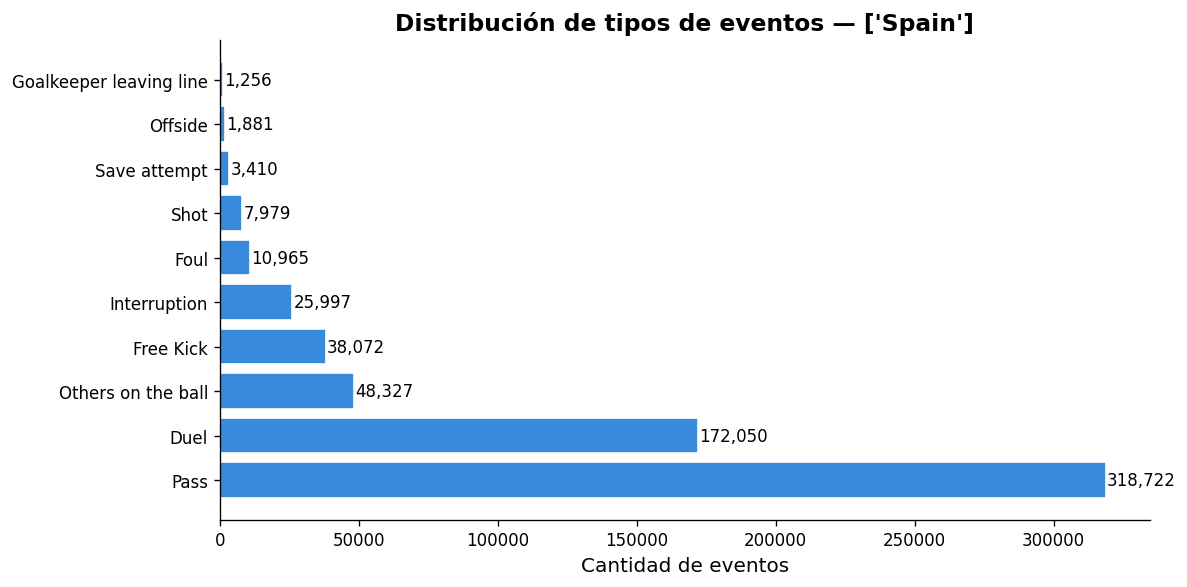

In [30]:
# Distribución de eventos
event_counts = df_events['eventName'].value_counts()

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(event_counts.index, event_counts.values, color='#378ADD', edgecolor='white')
ax.set_xlabel('Cantidad de eventos', fontsize=12)
ax.set_title(f"Distribución de tipos de eventos — {competitions}", fontsize=14, fontweight='bold')
ax.spines[['top','right']].set_visible(False)
for bar in bars:
    w = bar.get_width()
    ax.text(w + 500, bar.get_y() + bar.get_height()/2, f'{w:,}', va='center', fontsize=10)
plt.tight_layout()
plt.show()

## 2. Shot Maps — Mapa de tiros

El shot map es una de las visualizaciones más icónicas del análisis de fútbol.
Muestra la ubicación de cada tiro, diferenciando goles de tiros sin gol.

In [31]:
# Filtramos tiros al arco
# 🔧 CAMBIO: sumamos también los tiros libres directos (eventName=='Free Kick',
#    subEventName=='Free kick shot'), que Wyscout clasifica aparte de 'Shot' y por
#    eso quedaban afuera. Esto es lo que hacía que is_direct_fk en compute_shot_features
#    nunca pudiera activarse (ver Sección 4) — el fix real estaba acá, no en esa función.
es_tiro_de_juego       = df_events['eventName'] == 'Shot'
es_tiro_libre_directo  = (df_events['eventName'] == 'Free Kick') & (df_events['subEventName'] == 'Free kick shot')

df_shots = df_events[es_tiro_de_juego | es_tiro_libre_directo].copy()

print(f'Total de tiros: {len(df_shots):,}')
print(f'  - De juego: {es_tiro_de_juego.sum():,}')
print(f'  - Tiros libres directos: {es_tiro_libre_directo.sum():,}')
print(f'Goles: {df_shots["is_goal"].sum():,}')
print(f'Tasa de conversión: {df_shots["is_goal"].mean():.1%}')

Total de tiros: 8,432
  - De juego: 7,979
  - Tiros libres directos: 453
Goles: 912
Tasa de conversión: 10.8%


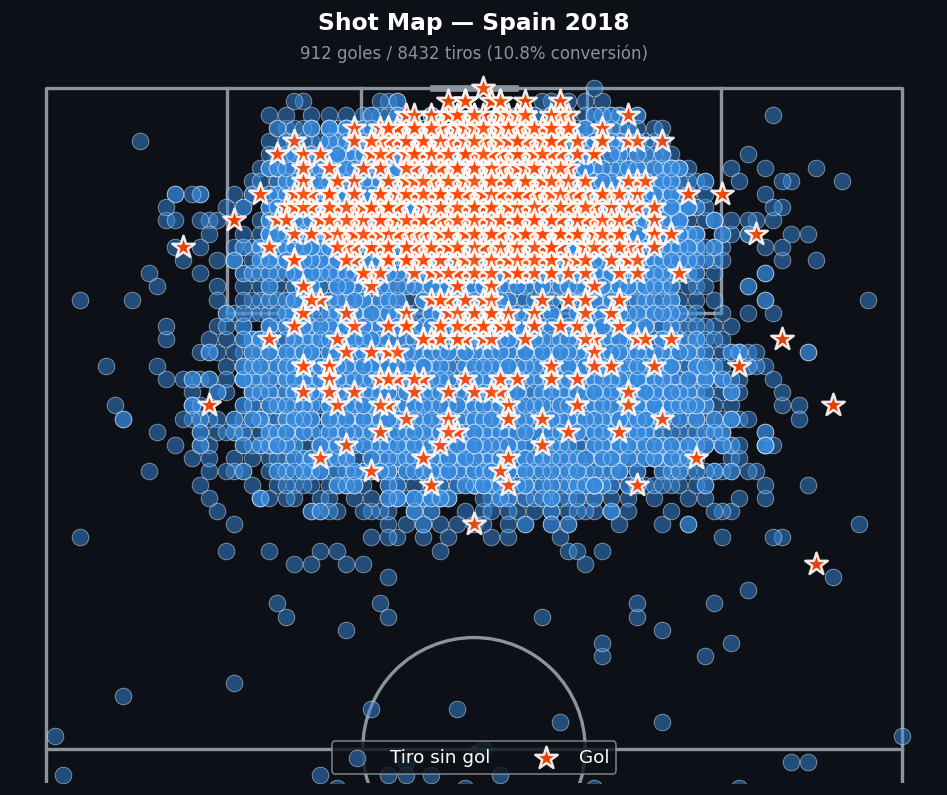

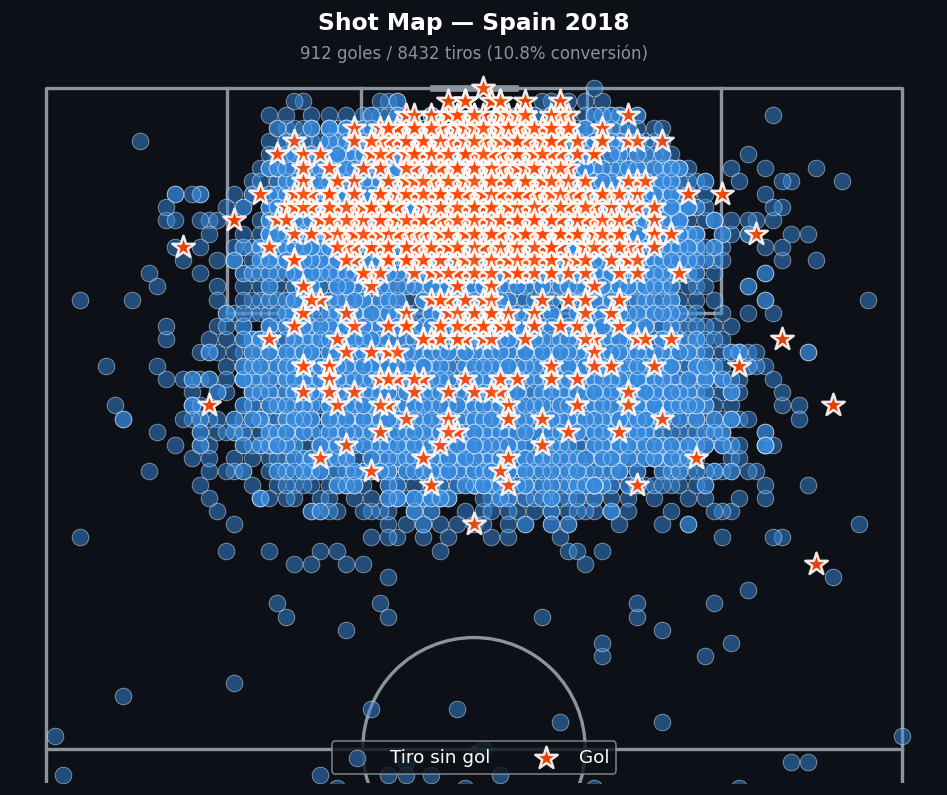

In [32]:
def plot_shot_map(df_shots, team_name=None, title=None):
    """
    Genera un shot map profesional con mplsoccer.
    
    Parámetros
    ----------
    df_shots  : DataFrame con columnas x_m, y_m, is_goal
    team_name : nombre del equipo (opcional, filtra)
    title     : título personalizado
    """
    data = df_shots.copy()
    if team_name:
        data = data[data['teamId'] == team_name]

    pitch = VerticalPitch(
        pitch_type='opta',
        pitch_color='#0d1117',
        line_color='#8b949e',
        half=True,
        line_zorder=2
    )
    fig, ax = pitch.draw(figsize=(8, 8), constrained_layout=True)
    fig.set_facecolor('#0d1117')

    # Tiros que no son gol
    no_goal = data[~data['is_goal']]
    pitch.scatter(
        no_goal['x'], no_goal['y'],
        s=100, alpha=0.5, edgecolors='white',
        linewidth=0.5, c='#378ADD', ax=ax, zorder=3,
        label='Tiro sin gol'
    )

    # Goles
    goals = data[data['is_goal']]
    pitch.scatter(
        goals['x'], goals['y'],
        s=200, alpha=0.9, edgecolors='white',
        linewidth=1.5, c='#FF4500', marker='*', ax=ax, zorder=4,
        label='Gol'
    )

    ax.legend(
        loc='lower center', ncol=2, fontsize=11,
        facecolor='#0d1117', edgecolor='#8b949e', labelcolor='white'
    )
    _title = title or f'Shot Map — {team_name or "Liga completa"}'
    ax.set_title(_title, color='white', fontsize=14, fontweight='bold', pad=15)
    ax.text(
        50, 102,
        f'{len(goals)} goles / {len(data)} tiros ({len(goals)/max(len(data),1):.1%} conversión)',
        ha='center', va='bottom', color='#8b949e', fontsize=10
    )

    plt.show()
    return fig

# Visualizamos la liga completa
plot_shot_map(df_shots, title=f"Shot Map — {competition} 2018")

## 3. Heat Maps — Densidad de acciones

Los heat maps permiten ver dónde en el campo ocurren más acciones de un tipo determinado.

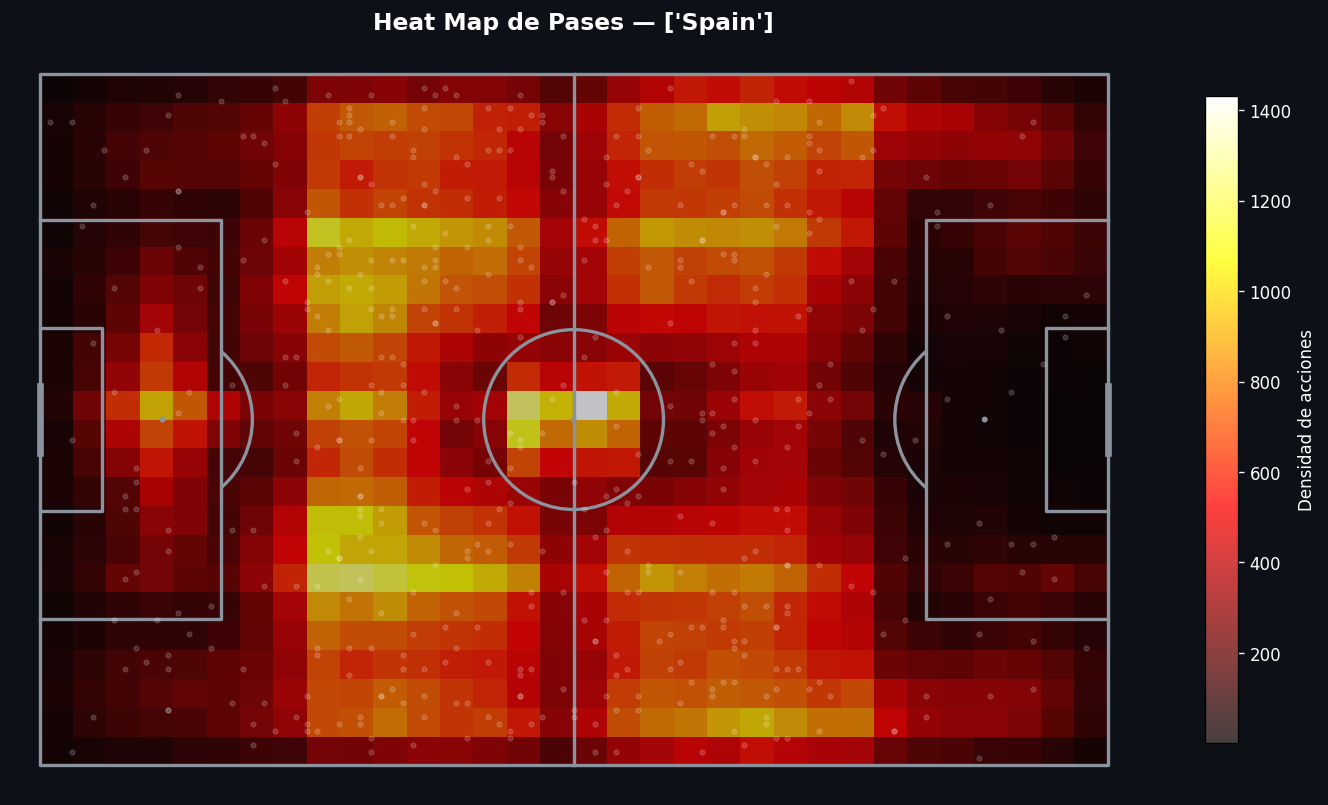

In [33]:
def plot_heatmap(df, event_type='Pass', team_id=None, cmap='hot', title=None):
    """
    Genera heat map por densidad de acciones (conteo binned en grilla).
    """
    data = df[df['eventName'] == event_type].copy()
    if team_id:
        data = data[data['teamId'] == team_id]
    data = data.dropna(subset=['x', 'y'])

    pitch = Pitch(
        pitch_type='opta',
        pitch_color='#0d1117',
        line_color='#8b949e',
        line_zorder=2
    )
    fig, ax = pitch.draw(figsize=(12, 8))
    fig.set_facecolor('#0d1117')

    # KDE a través de mplsoccer (gestiona bien el campo)
    bs = pitch.bin_statistic(
        data['x'], data['y'], statistic='count', bins=(32, 24)
    )
    heatmap = pitch.heatmap(bs, ax=ax, cmap=cmap, edgecolors='none', alpha=0.75)
    pitch.scatter(
        data['x'].sample(min(500, len(data))), 
        data['y'].sample(min(500, len(data))),
        s=8, alpha=0.15, color='white', ax=ax, zorder=5
    )

    cbar = fig.colorbar(heatmap, ax=ax, shrink=0.7)
    cbar.set_label('Densidad de acciones', color='white')
    cbar.ax.yaxis.set_tick_params(color='white')
    plt.setp(cbar.ax.yaxis.get_ticklabels(), color='white')

    _title = title or f'Heat Map — {event_type}'
    ax.set_title(_title, color='white', fontsize=14, fontweight='bold', pad=10)
    plt.tight_layout()
    plt.show()

plot_heatmap(df_events, event_type='Pass', title=f"Heat Map de Pases — {competitions}")

Extraigo todos los equipos únicos de los partidos en df_matches

In [34]:
all_team_ids = set()

for teams_data in df_matches['teamsData']:
    all_team_ids.update(teams_data.keys())

df_team_ids = pd.DataFrame(
    {'team_id': sorted(map(int, all_team_ids))}
)

df_team_ids = (
    df_team_ids
    .merge(
        teams[['wyId', 'name']],
        left_on='team_id',
        right_on='wyId',
        how='left'
    )
    .drop(columns='wyId')
)

df_team_ids

,team_id,name
0,674,Valencia
1,675,Real Madrid
2,676,Barcelona
3,677,Deportivo La Coruña
4,678,Athletic Club
5,679,Atlético Madrid
6,680,Sevilla
7,682,Villarreal
8,683,Málaga
9,684,Real Betis


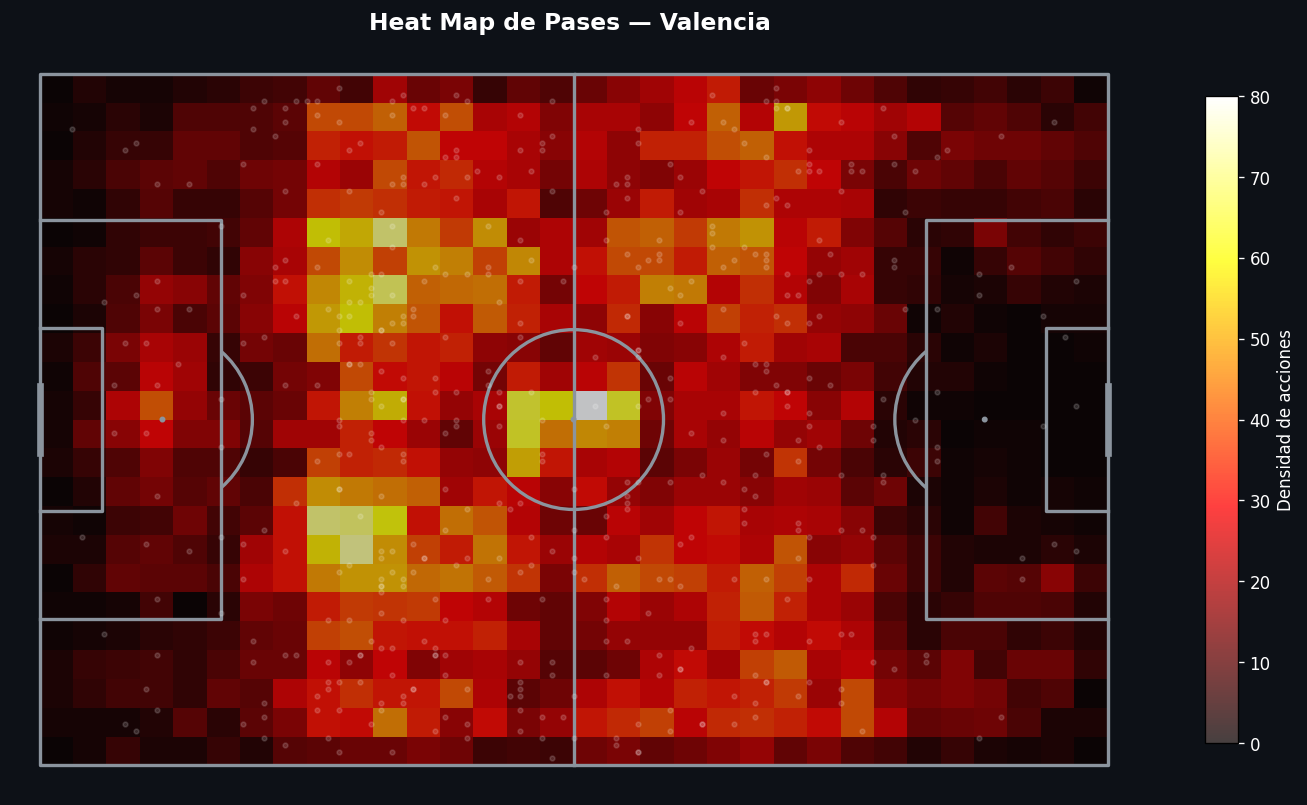

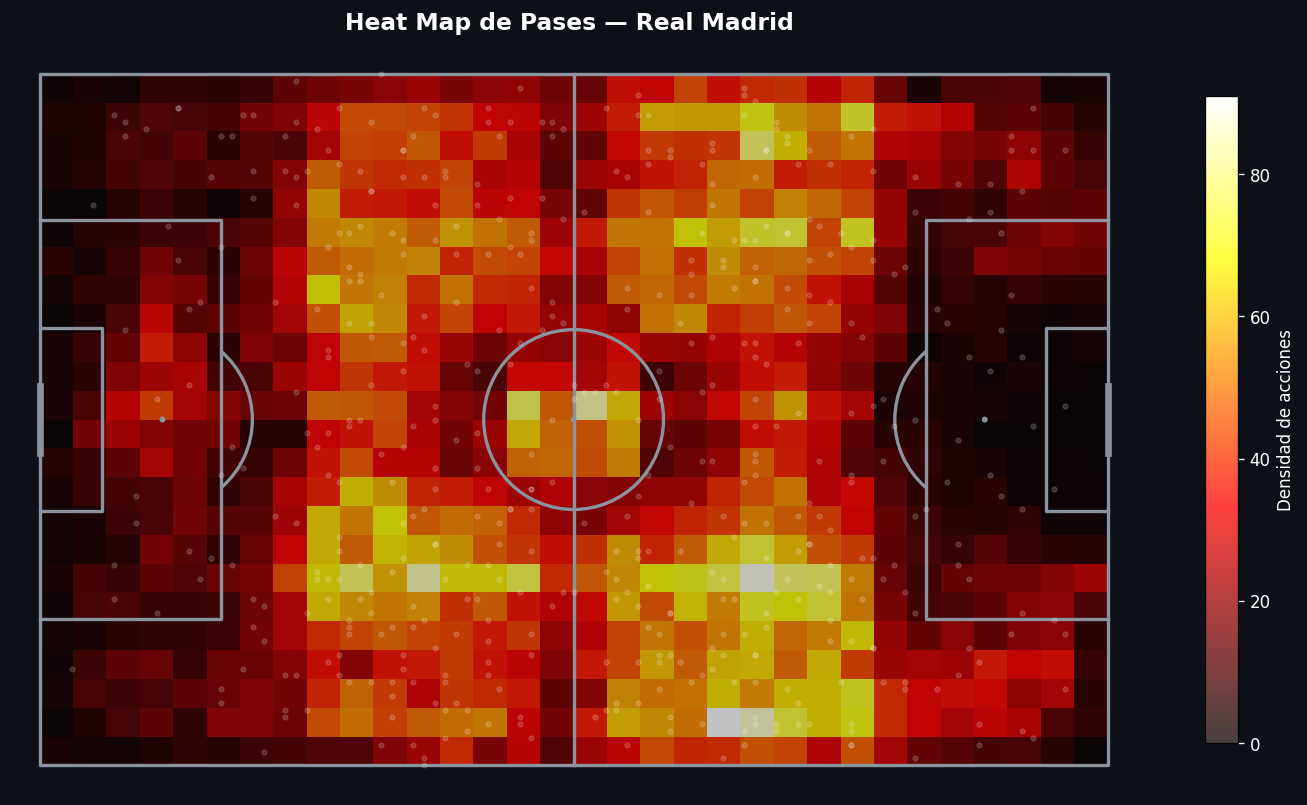

In [35]:
plot_heatmap(df_events, event_type='Pass', team_id=df_team_ids.loc[0,'team_id'], title=f"Heat Map de Pases — {df_team_ids.loc[0,'name']} ")
plot_heatmap(df_events, event_type='Pass', team_id=df_team_ids.loc[1,'team_id'], title=f"Heat Map de Pases — {df_team_ids.loc[1,'name']} ")

## 4. Expected Goals (xG)

xG es la métrica central del análisis moderno. Estima la probabilidad de que un tiro
se convierta en gol basándose en la posición y otras características.

Vamos a implementar un modelo xG simple usando regresión logística.

In [36]:
# Se incorporan correcciones en el código, x consejo del Claudio.

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score
from sklearn.metrics import roc_auc_score, brier_score_loss
import matplotlib.patches as patches

def compute_shot_features(df_shots):
    """
    Computa features geométricas para el modelo xG.
    Referencia: Caley (2013), Lucey et al. (2014)
    """
    df = df_shots.copy()

    # Coordenadas en metros (campo 105x68)
    # En Wyscout, el arco atacante está en x=100
    df['dist_goal'] = np.sqrt(
        ((100 - df['x']) / 100 * 105) ** 2 +
        ((50 - df['y'])  / 100 * 68)  ** 2
    )

    # Ángulo al arco (radianes → grados)
    # 🔧 CAMBIO: postes recalculados para dar el ancho reglamentario exacto (7.32m).
    #    Los valores originales (44.2 / 55.8) daban 7.89m, ~7.8% de más.
    post_left  = 44.62
    post_right = 55.38

    # 🔧 CAMBIO: convertimos x, y y los postes a metros ANTES de calcular a, b, c.
    #    Antes se mezclaban unidades del eje x (0-100 = 105m) con las del eje y (0-100 = 68m)
    #    como si fueran la misma escala. Verificado empíricamente: esto distorsionaba
    #    angle_goal hasta un 33% en tiros cerca y centrados (justamente los de mayor xG).
    x_m = df['x'] / 100 * 105
    y_m = df['y'] / 100 * 68
    post_left_m  = post_left  / 100 * 68
    post_right_m = post_right / 100 * 68

    a = np.sqrt((105 - x_m) ** 2 + (post_left_m  - y_m) ** 2)
    b = np.sqrt((105 - x_m) ** 2 + (post_right_m - y_m) ** 2)
    c = post_right_m - post_left_m  # ancho del arco, ahora en metros

    # Ley del coseno (la fórmula en sí no cambia, solo las unidades que recibe)
    cos_angle = (a ** 2 + b ** 2 - c ** 2) / (2 * a * b + 1e-9)
    df['angle_goal'] = np.degrees(np.arccos(cos_angle.clip(-1, 1)))

    # 🔧 CAMBIO: is_head ahora usa el tag real de Wyscout (403 = head/body, confirmado
    #    en tags2name.csv) en vez de buscar "head" en subEventName. Para eventName=='Shot',
    #    subEventName vale siempre literalmente "Shot" — la versión original nunca
    #    matcheaba nada (columna constante en 0, coeficiente 0.0000 en el modelo).
    #    Requiere que df_shots tenga la columna 'tag_ids' (se arma en la Sección 1.4).
    df['is_head'] = df['tag_ids'].apply(lambda t: 403 in t).astype(int)

    # ✅ Antes dependía de que df_shots incluyera los tiros libres directos (ver Sección 2,
    #    corregido). Ahora sí detecta señal real.
    df['is_direct_fk'] = df['subEventName'].str.lower().str.contains('free kick', na=False).astype(int)

    return df


df_shots_fe = compute_shot_features(df_shots.dropna(subset=['x', 'y']))

features = ['dist_goal', 'angle_goal', 'is_head', 'is_direct_fk']
X = df_shots_fe[features].fillna(0).values
y = df_shots_fe['is_goal'].astype(int).values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Modelo de regresión logística (baseline xG)
model_xg = LogisticRegression(max_iter=1000, C=0.5)
auc_scores = cross_val_score(model_xg, X_scaled, y, cv=5, scoring='roc_auc')
model_xg.fit(X_scaled, y)
df_shots_fe['xG'] = model_xg.predict_proba(X_scaled)[:, 1]

print(f'AUC (5-fold CV): {auc_scores.mean():.4f} ± {auc_scores.std():.4f}')
print(f'Brier Score: {brier_score_loss(y, df_shots_fe["xG"]):.4f}')
print(f'\nTotal xG en la liga: {df_shots_fe["xG"].sum():.1f}')
print(f'Goles reales: {y.sum()}')

AUC (5-fold CV): 0.7782 ± 0.0106
Brier Score: 0.0835

Total xG en la liga: 911.4
Goles reales: 912


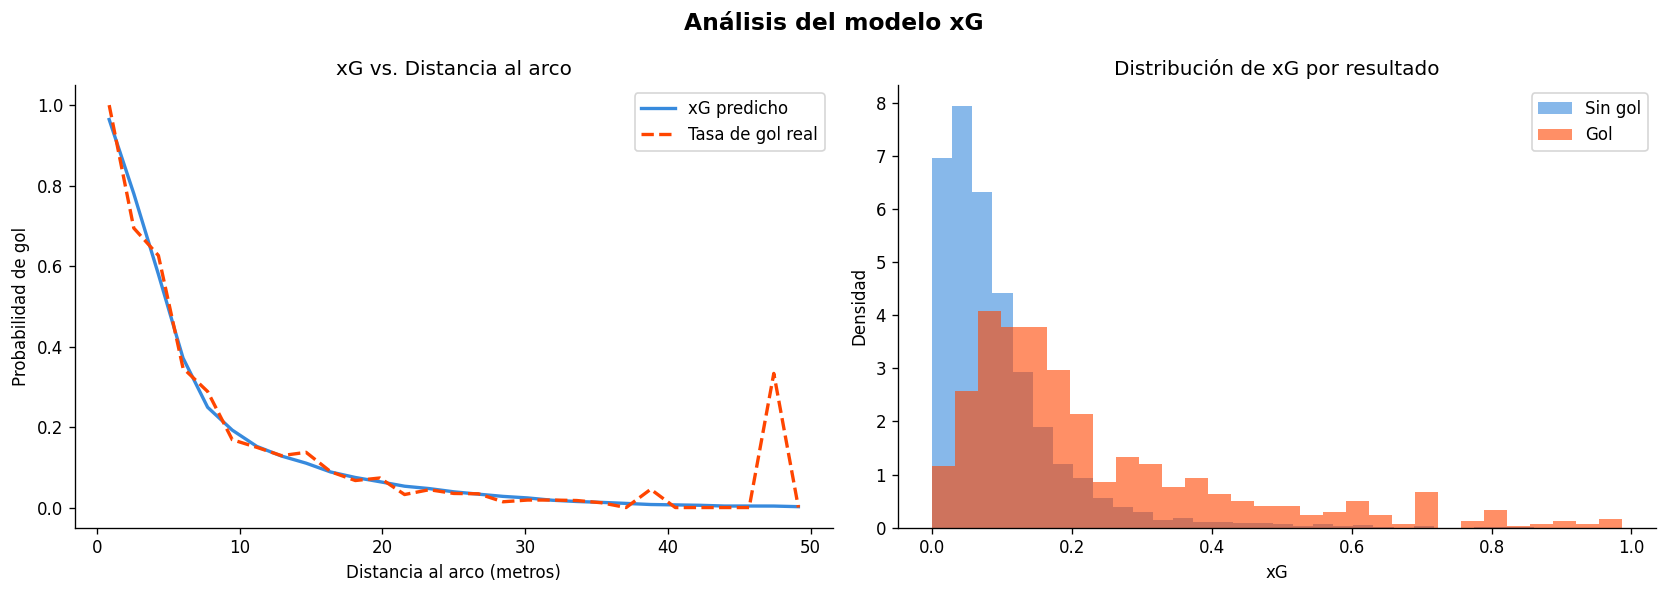

In [37]:
# Visualización: xG vs distancia al arco
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Análisis del modelo xG', fontsize=14, fontweight='bold')

# Panel izq: xG vs distancia
ax = axes[0]
# Curva promedio
dist_bins = np.linspace(0, 50, 30)
df_shots_fe['dist_bin'] = pd.cut(df_shots_fe['dist_goal'], bins=dist_bins)
avg_xg = df_shots_fe.groupby('dist_bin')['xG'].mean()
avg_goal = df_shots_fe.groupby('dist_bin')['is_goal'].mean()
bin_centers = [i.mid for i in avg_xg.index]

ax.plot(bin_centers, avg_xg.values, color='#378ADD', linewidth=2, label='xG predicho')
ax.plot(bin_centers, avg_goal.values, color='#FF4500', linewidth=2, linestyle='--', label='Tasa de gol real')
ax.set_xlabel('Distancia al arco (metros)')
ax.set_ylabel('Probabilidad de gol')
ax.set_title('xG vs. Distancia al arco')
ax.legend()
ax.spines[['top','right']].set_visible(False)

# Panel der: distribución de xG por categoría
ax2 = axes[1]
for is_goal, label, color in [(0, 'Sin gol', '#378ADD'), (1, 'Gol', '#FF4500')]:
    vals = df_shots_fe.loc[df_shots_fe['is_goal'] == is_goal, 'xG']
    ax2.hist(vals, bins=30, alpha=0.6, label=label, color=color, density=True)
ax2.set_xlabel('xG')
ax2.set_ylabel('Densidad')
ax2.set_title('Distribución de xG por resultado')
ax2.legend()
ax2.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.show()

In [46]:
import matplotlib.patheffects as pe

In [47]:
def build_passing_network(df_events, match_id, team_id):
    """
    Construye una red de pases para un partido y equipo específicos.
    Retorna nodos (posición media) y aristas (conexiones de pase).
    """
    df_match_all = df_events[df_events['matchId'] == match_id].sort_values(
        ['matchPeriod', 'eventSec']
    ).reset_index(drop=True)

    df_match_all['next_player'] = df_match_all['playerId'].shift(-1)
    df_match_all['next_teamId'] = df_match_all['teamId'].shift(-1)

    mask = (df_match_all['teamId'] == team_id) & (df_match_all['eventName'] == 'Pass')
    df_match_passes = df_match_all[mask].copy()

    nodes = df_match_passes.groupby('playerId').agg(
        x=('x', 'mean'),
        y=('y', 'mean'),
        passes_made=('eventId', 'count')
    ).reset_index()

    sin_perdida = df_match_passes['next_teamId'] == team_id
    edges = df_match_passes[sin_perdida].groupby(
        ['playerId', 'next_player']
    ).size().reset_index(name='count')
    edges = edges[edges['count'] >= 3]

    return nodes, edges

In [48]:
def build_passing_network(df_events, match_id, team_id):
    """
    Construye una red de pases para un partido y equipo específicos.
    Retorna nodos (posición media) y aristas (conexiones de pase).
    """
    df_match_all = df_events[df_events['matchId'] == match_id].sort_values(
        ['matchPeriod', 'eventSec']
    ).reset_index(drop=True)

    df_match_all['next_player'] = df_match_all['playerId'].shift(-1)
    df_match_all['next_teamId'] = df_match_all['teamId'].shift(-1)

    mask = (df_match_all['teamId'] == team_id) & (df_match_all['eventName'] == 'Pass')
    df_match_passes = df_match_all[mask].copy()

    nodes = df_match_passes.groupby('playerId').agg(
        x=('x', 'mean'),
        y=('y', 'mean'),
        passes_made=('eventId', 'count')
    ).reset_index()

    sin_perdida = df_match_passes['next_teamId'] == team_id
    edges = df_match_passes[sin_perdida].groupby(
        ['playerId', 'next_player']
    ).size().reset_index(name='count')
    edges = edges[edges['count'] >= 3]

    return nodes, edges

In [49]:
def plot_passing_network(nodes, edges, players_df=None, title='Red de Pases'):
    """
    Visualiza la red de pases sobre el campo.
    """
    pitch = Pitch(
        pitch_type='opta', pitch_color='#1a472a',
        line_color='#ffffff', line_zorder=2
    )
    fig, ax = pitch.draw(figsize=(14, 9))
    fig.set_facecolor('#0d1117')

    max_count = edges['count'].max() if len(edges) > 0 else 1
    for _, edge in edges.iterrows():
        src = nodes[nodes['playerId'] == edge['playerId']]
        dst = nodes[nodes['playerId'] == edge['next_player']]
        if src.empty or dst.empty:
            continue
        alpha = 0.3 + 0.6 * (edge['count'] / max_count)
        lw = 1 + 4 * (edge['count'] / max_count)
        ax.plot(
            [src['x'].values[0], dst['x'].values[0]],
            [src['y'].values[0], dst['y'].values[0]],
            color='white', alpha=alpha, linewidth=lw, zorder=3
        )

    max_passes = nodes['passes_made'].max() if len(nodes) > 0 else 1
    scatter_size = 200 + 800 * (nodes['passes_made'] / max_passes)
    sc = pitch.scatter(
        nodes['x'], nodes['y'],
        s=scatter_size, c=nodes['passes_made'], cmap='YlOrRd',
        edgecolors='white', linewidth=1.5, ax=ax, zorder=5
    )

    # Etiquetas con el nombre de cada jugador
    if players_df is not None:
        nombres = players_df.set_index('wyId')['shortName']
        for _, node in nodes.iterrows():
            nombre = nombres.get(node['playerId'], str(int(node['playerId'])))
            ax.annotate(
                nombre,
                xy=(node['x'], node['y']),
                xytext=(0, 12), textcoords='offset points',
                ha='center', va='center',
                color='white', fontsize=8, fontweight='bold',
                path_effects=[pe.withStroke(linewidth=2, foreground='#0d1117')],
                zorder=6
            )

    plt.colorbar(sc, ax=ax, label='Pases realizados', shrink=0.6)
    ax.set_title(title, color='white', fontsize=14, fontweight='bold', pad=12)
    plt.tight_layout()
    plt.show()

Nodos: 13, Aristas (≥3 pases): 44


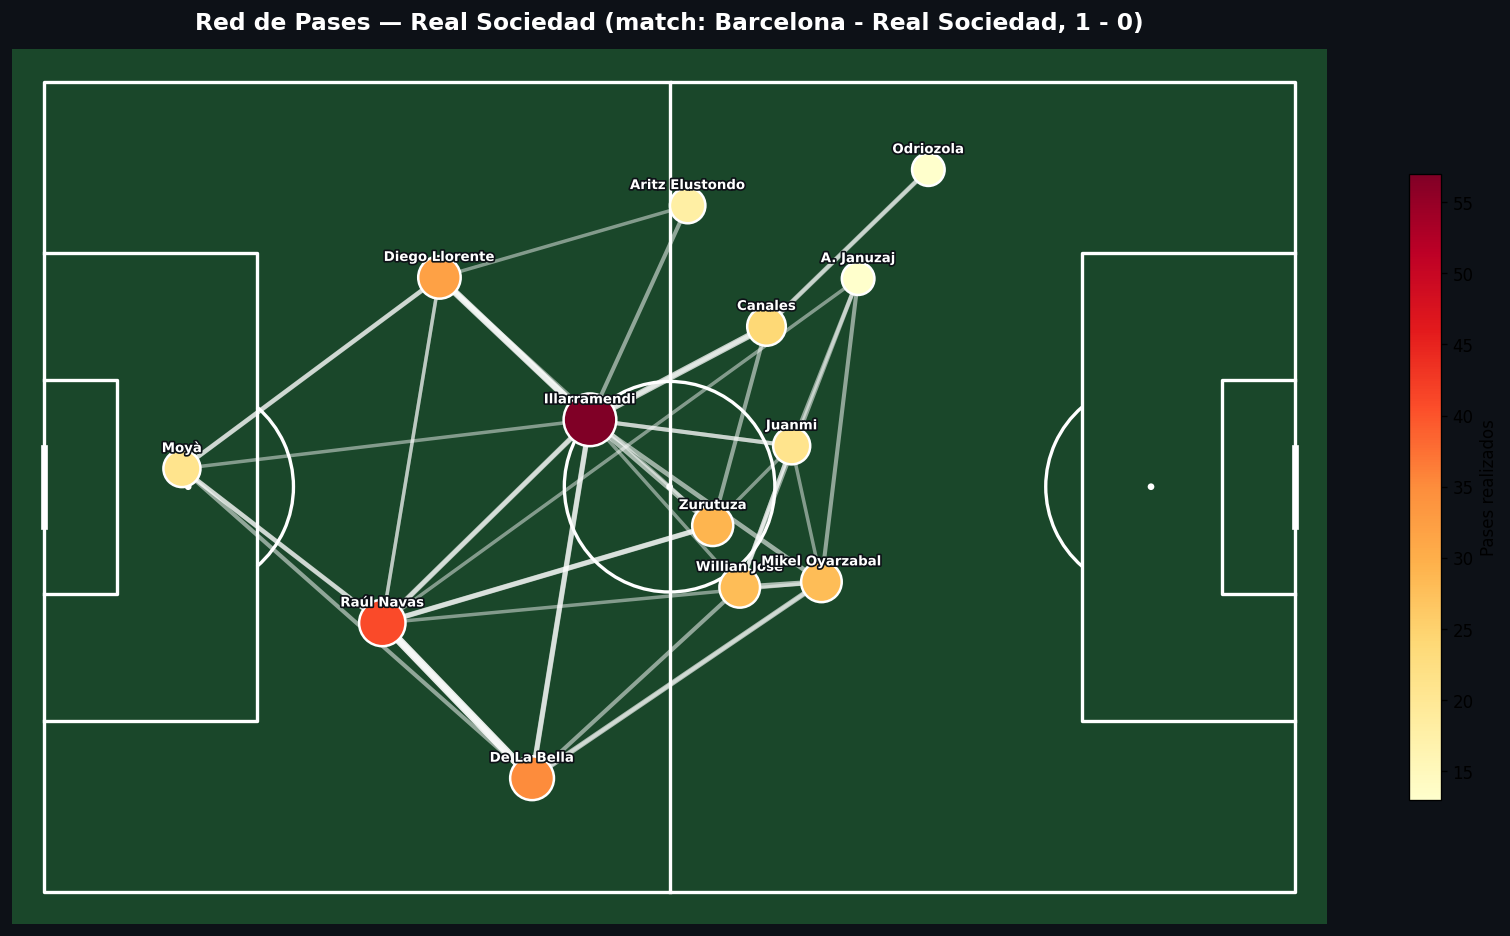

In [52]:
first_match_id = df_matches['wyId'].iloc[0]
teams_in_match = df_events[df_events['matchId'] == first_match_id]['teamId'].unique()

if len(teams_in_match) >= 1:
    team_id = teams_in_match[0]
    team_name = teams[teams['wyId'] == team_id]['name'].values
    team_name = team_name[0] if len(team_name) else str(team_id)
    legend = df_matches.loc[df_matches['wyId'] == first_match_id, 'label'].iat[0]

    nodes, edges = build_passing_network(df_events, first_match_id, team_id)
    print(f'Nodos: {len(nodes)}, Aristas (≥3 pases): {len(edges)}')

    plot_passing_network(
        nodes, edges,
        players_df=players,
        title=f'Red de Pases — {team_name} (match: {legend})'
    )

In [51]:
# Filtramos goles convertidos desde más de 40 metros, con la variable is_direct_fk
# para distinguir tiro libre de jugada abierta (sin excluir ninguno de los dos tipos)
tiros_lejanos_gol = df_shots_fe[
    (df_shots_fe['dist_goal'] > 40) &
    (df_shots_fe['is_goal'] == True)
].copy()

# Le sumamos el nombre del jugador para que sea legible
tiros_lejanos_gol = tiros_lejanos_gol.merge(
    players[['wyId', 'shortName']],
    left_on='playerId', right_on='wyId', how='left'
).drop(columns='wyId')

print(f'Total de goles desde más de 40 metros: {len(tiros_lejanos_gol)}')
print(f'  - Tiro libre directo: {tiros_lejanos_gol["is_direct_fk"].sum()}')
print(f'  - De juego (no tiro libre): {(tiros_lejanos_gol["is_direct_fk"] == 0).sum()}')

tiros_lejanos_gol[
    ['shortName', 'matchId', 'dist_goal', 'angle_goal', 'is_direct_fk', 'is_head']
].sort_values('dist_goal', ascending=False)

Total de goles desde más de 40 metros: 2
  - Tiro libre directo: 1
  - De juego (no tiro libre): 1


,shortName,matchId,dist_goal,angle_goal,is_direct_fk,is_head
1,Pablo Sarabia,2565775,103.952224,4.031081,0,0
0,P. Sisto,2565606,46.569088,7.312429,1,0


## 5. Redes de Pases (Passing Networks)

Las redes de pases muestran cómo circula el balón entre los jugadores de un equipo.
Son una herramienta central para el análisis táctico moderno.

In [40]:
def build_passing_network(df_events, match_id, team_id):
    """
    Construye una red de pases para un partido y equipo específicos.
    Retorna nodos (posición media) y aristas (conexiones de pase).
    """
    # 🔧 CAMBIO: partimos de TODOS los eventos del partido (no solo los pases del equipo),
    #    ordenados cronológicamente, para poder detectar si hubo una pérdida de posesión
    #    real entre un pase y el siguiente. Antes se filtraba a pases del equipo ANTES de
    #    calcular "next_player", lo que hacía que el código saltara por encima de duelos,
    #    regates, y recuperaciones del rival, conectando jugadores que en realidad no se
    #    pasaron la pelota directamente.
    df_match_all = df_events[df_events['matchId'] == match_id].sort_values(
        ['matchPeriod', 'eventSec']
    ).reset_index(drop=True)

    df_match_all['next_player'] = df_match_all['playerId'].shift(-1)
    df_match_all['next_teamId'] = df_match_all['teamId'].shift(-1)

    # Ahora sí filtramos a los pases del equipo, pero ya con el contexto del
    # "próximo evento real" calculado sobre el partido completo.
    mask = (df_match_all['teamId'] == team_id) & (df_match_all['eventName'] == 'Pass')
    df_match_passes = df_match_all[mask].copy()

    # Posición media de cada jugador (nodo) — sin cambios
    nodes = df_match_passes.groupby('playerId').agg(
        x=('x', 'mean'),
        y=('y', 'mean'),
        passes_made=('eventId', 'count')
    ).reset_index()

    # 🔧 CAMBIO: solo contamos una conexión si el evento inmediato siguiente (de cualquier
    #    tipo, no solo pase) es del MISMO equipo — es decir, sin pérdida de posesión en el
    #    medio. Verificado empíricamente con un partido real: ~23% de los pases de un
    #    equipo terminan en pérdida inmediata, y el método anterior generaba ~24% de
    #    aristas espurias por ignorar justamente esos casos.
    sin_perdida = df_match_passes['next_teamId'] == team_id
    edges = df_match_passes[sin_perdida].groupby(
        ['playerId', 'next_player']
    ).size().reset_index(name='count')

    # Solo aristas con al menos 3 pases (sin cambios)
    edges = edges[edges['count'] >= 3]
    return nodes, edges


def plot_passing_network(nodes, edges, title='Red de Pases'):
    """
    Visualiza la red de pases sobre el campo.
    """
    # ✅ Sin cambios — esta función ya estaba bien. Revisé la lógica de escalado de
    #    grosor/alpha en las aristas y tamaño/color en los nodos, no encontré problemas.
    pitch = Pitch(
        pitch_type='opta', pitch_color='#1a472a',
        line_color='#ffffff', line_zorder=2
    )
    fig, ax = pitch.draw(figsize=(14, 9))
    fig.set_facecolor('#0d1117')
    max_count = edges['count'].max() if len(edges) > 0 else 1
    for _, edge in edges.iterrows():
        src = nodes[nodes['playerId'] == edge['playerId']]
        dst = nodes[nodes['playerId'] == edge['next_player']]
        if src.empty or dst.empty:
            continue
        alpha  = 0.3 + 0.6 * (edge['count'] / max_count)
        lw     = 1 + 4 * (edge['count'] / max_count)
        ax.plot(
            [src['x'].values[0], dst['x'].values[0]],
            [src['y'].values[0], dst['y'].values[0]],
            color='white', alpha=alpha, linewidth=lw, zorder=3
        )
    max_passes = nodes['passes_made'].max() if len(nodes) > 0 else 1
    scatter_size = 200 + 800 * (nodes['passes_made'] / max_passes)
    sc = pitch.scatter(
        nodes['x'], nodes['y'],
        s=scatter_size,
        c=nodes['passes_made'],
        cmap='YlOrRd',
        edgecolors='white', linewidth=1.5,
        ax=ax, zorder=5
    )
    plt.colorbar(sc, ax=ax, label='Pases realizados', shrink=0.6)
    ax.set_title(title, color='white', fontsize=14, fontweight='bold', pad=12)
    plt.tight_layout()
    plt.show()


In [41]:
# Ejemplo de uso 
print('Primeros partidos disponibles:')
print(df_matches[['wyId','label']].head(5))

Primeros partidos disponibles:
      wyId                                  label
0  2565922       Barcelona - Real Sociedad, 1 - 0
1  2565925         Atlético Madrid - Eibar, 2 - 2
2  2565919        Athletic Club - Espanyol, 0 - 1
3  2565924  Valencia - Deportivo La Coruña, 2 - 1
4  2565927        Villarreal - Real Madrid, 2 - 2


Nodos: 14, Aristas (≥3 pases): 68


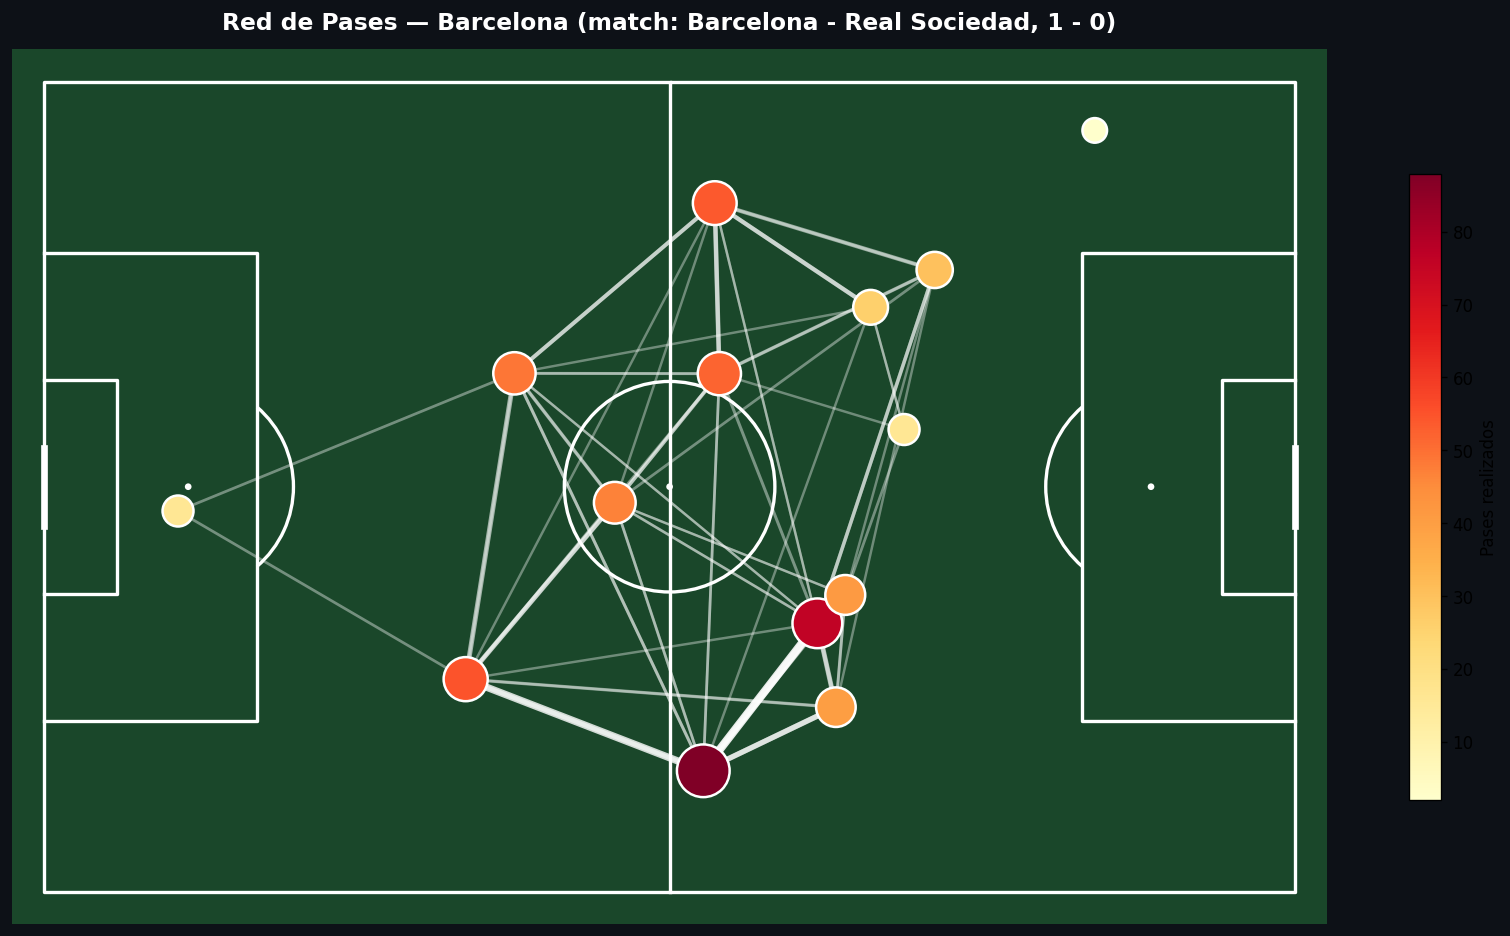

In [45]:
# Seleccionamos el primer partido disponible
first_match_id = df_matches['wyId'].iloc[0]

# Encontramos los dos equipos del partido
teams_in_match = df_events[
    df_events['matchId'] == first_match_id
]['teamId'].unique()

if len(teams_in_match) >= 1:
    team_id = teams_in_match[1]
    team_name = teams[teams['wyId'] == team_id]['name'].values
    team_name = team_name[0] if len(team_name) else str(team_id)
    legend = df_matches.loc[df_matches['wyId']==first_match_id,'label'].iat[0]
    nodes, edges = build_passing_network(df_events, first_match_id, team_id)
    print(f'Nodos: {len(nodes)}, Aristas (≥3 pases): {len(edges)}')

    plot_passing_network(
        nodes, edges,
        title=f'Red de Pases — {team_name} (match: {legend})'
    )

In [25]:
# Ver algunas estadísticas para obtener otras estadísticas relevantes

players_lookup = players.set_index('wyId')

def resumen_red(nodes, edges):
    """
    Arma una tabla resumen de la red de pases: nombre, rol, pases dados/recibidos
    y cantidad de conexiones distintas (≥3 pases) por jugador.
    """
    tabla = nodes.copy()
    tabla['nombre'] = tabla['playerId'].map(players_lookup['shortName'])
    tabla['rol'] = tabla['playerId'].map(
        lambda pid: players_lookup.loc[pid, 'role']['code3'] if pid in players_lookup.index else None
    )

    # Pases recibidos: sumamos el 'count' de las aristas donde el jugador es el receptor (next_player)
    recibidos = edges.groupby('next_player')['count'].sum().rename('pases_recibidos')
    tabla = tabla.merge(recibidos, left_on='playerId', right_index=True, how='left')
    tabla['pases_recibidos'] = tabla['pases_recibidos'].fillna(0).astype(int)

    # Grado: con cuántos compañeros distintos conecta (dando o recibiendo, con >=3 pases)
    conex_dadas = edges.groupby('playerId')['next_player'].nunique()
    conex_recib = edges.groupby('next_player')['playerId'].nunique()
    tabla['conexiones_distintas'] = (
        tabla['playerId'].map(conex_dadas).fillna(0) + tabla['playerId'].map(conex_recib).fillna(0)
    ).astype(int)

    return tabla[
        ['playerId', 'nombre', 'rol', 'passes_made', 'pases_recibidos', 'conexiones_distintas', 'x', 'y']
    ].sort_values('passes_made', ascending=False)


tabla_red = resumen_red(nodes, edges)
tabla_red

,playerId,nombre,rol,passes_made,pases_recibidos,conexiones_distintas,x,y
2,8351,A. Surman,MID,55,30,11,47.600000,40.000000
5,9285,C. Daniels,DEF,51,36,12,51.745098,10.196078
11,239411,T. Mings,DEF,45,26,9,36.488889,25.733333
4,9277,S. Cook,DEF,40,8,6,32.000000,76.400000
9,62224,R. Fraser,MID,30,17,8,52.000000,85.066667
10,134102,N. Aké,DEF,30,12,7,32.733333,43.666667
7,9739,J. Ibe,MID,29,12,4,56.862069,60.413793
12,245813,L. Mousset,FWD,23,21,6,55.434783,27.869565
13,259531,E. Hyndman,MID,23,4,3,50.000000,47.956522
3,8726,A. Begović,GKP,17,6,2,8.470588,56.058824


## 6. Radar Charts — Comparación de jugadores

Los radares son la forma más usada para comparar perfiles de jugadores.
Vamos a crear radares con normalización por percentil respecto a la liga.

In [30]:
# 🆕 CELDA NUEVA: calculamos minutos jugados por jugador en toda la temporada,
#    a partir de las alineaciones y sustituciones de matches.json (df_matches).
#    Sin esto no se puede normalizar nada "por 90 minutos".
def minutos_por_partido(teams_data, match_length=90):
    """Devuelve {playerId: minutos_jugados} para un partido, a partir de teamsData."""
    minutos = {}
    for team_id_str, team_info in teams_data.items():
        formation = team_info.get('formation', {})
        if not isinstance(formation, dict):
            continue
        lineup = formation.get('lineup', [])
        # ⚠️ En ~5 de 760 casos, 'substitutions' viene como el string "null" en vez de
        #    una lista vacía (inconsistencia del JSON fuente) — nos defendemos de eso.
        subs_raw = formation.get('substitutions', [])
        subs = sorted(subs_raw, key=lambda s: s['minute']) if isinstance(subs_raw, list) else []
        en_cancha_desde = {p['playerId']: 0 for p in lineup}
        for sub in subs:
            pid_out, pid_in, minute = sub['playerOut'], sub['playerIn'], sub['minute']
            if pid_out in en_cancha_desde:
                minutos[pid_out] = minutos.get(pid_out, 0) + (minute - en_cancha_desde[pid_out])
                del en_cancha_desde[pid_out]
            en_cancha_desde[pid_in] = minute
        # Los que quedaron en cancha hasta el final del partido
        for pid, desde in en_cancha_desde.items():
            minutos[pid] = minutos.get(pid, 0) + (match_length - desde)
    return minutos

minutos_totales = {}
for _, row in df_matches.iterrows():
    for pid, mins in minutos_por_partido(row['teamsData']).items():
        minutos_totales[pid] = minutos_totales.get(pid, 0) + mins

df_minutos = pd.DataFrame(list(minutos_totales.items()), columns=['playerId', 'minutes_played'])
print(f'Jugadores con minutos calculados: {len(df_minutos)}')

Jugadores con minutos calculados: 515


In [31]:
def build_player_stats(df_events, players_df, df_minutos, df_shots_fe, min_minutes=500):
    """
    Agrega estadísticas por jugador para construir perfiles.
    Retorna estadísticas normalizadas por 90 minutos.
    """
    passes = df_events[df_events['eventName'] == 'Pass'].groupby('playerId').agg(
        total_passes=('eventId', 'count')
    ).reset_index()

    shots = df_events[df_events['eventName'] == 'Shot'].groupby('playerId').agg(
        total_shots=('eventId', 'count'),
        total_goals=('is_goal', 'sum')
    ).reset_index()

    # 🔧 CAMBIO: xG real, sacado de df_shots_fe (Ejercicio 2), no del fallback que
    #    silenciosamente terminaba copiando total_shots bajo el nombre "total_xg".
    xg = df_shots_fe.groupby('playerId')['xG'].sum().reset_index().rename(columns={'xG': 'total_xg'})

    # 🔧 CAMBIO: separamos duelos totales de duelos GANADOS (tag 703='won' en Wyscout),
    #    que es lo que pide el Ejercicio 4, no duelos totales.
    duels_all = df_events[df_events['eventName'] == 'Duel']
    duels_total = duels_all.groupby('playerId').agg(total_duels=('eventId', 'count')).reset_index()
    duels_won = duels_all[duels_all['tag_ids'].apply(lambda t: 703 in t)].groupby('playerId').agg(
        total_duels_won=('eventId', 'count')
    ).reset_index()

    # 🔧 CAMBIO: renombrado honesto — esto NO son "carries" (conducciones de balón, un
    #    concepto distinto no implementado acá) ni "tiros libres" puros. eventName=='Free Kick'
    #    en Wyscout mezcla saques de banda, corners, saques de arco, tiros libres y penales.
    #    Lo dejamos con nombre honesto; separar cada subtipo queda fuera de este alcance.
    set_pieces = df_events[df_events['eventName'] == 'Free Kick'].groupby('playerId').agg(
        set_pieces_taken=('eventId', 'count')
    ).reset_index()

    stats = passes
    for df_merge in [shots, xg, duels_total, duels_won, set_pieces]:
        stats = stats.merge(df_merge, on='playerId', how='outer')
    stats = stats.fillna(0)

    # 🔧 CAMBIO: unimos minutos jugados, y de paso esto filtra automáticamente cualquier
    #    playerId "placeholder" (como el 0, que no tiene alineación real en ningún partido
    #    y antes contaminaba el top de duelos con 18.115 — 13x el jugador real con más).
    stats = stats.merge(df_minutos, on='playerId', how='inner')
    # Cinturón y tirantes: también exigimos que el playerId exista en players.json
    stats = stats.merge(players_df[['wyId']], left_on='playerId', right_on='wyId', how='inner').drop(columns='wyId')

    # 🔧 CAMBIO: el parámetro min_minutes ahora SE USA — antes estaba declarado y nunca
    #    se aplicaba. Sin este filtro, un jugador con pocos minutos y un golazo de suerte
    #    podía mostrar una tasa por 90 absurda.
    stats = stats[stats['minutes_played'] >= min_minutes].copy()

    # 🔧 CAMBIO: acá está la normalización "por 90 minutos" que el docstring siempre dijo
    #    que hacía, y que antes no existía en ningún lado del código.
    for col in ['total_passes', 'total_shots', 'total_goals', 'total_xg', 'total_duels', 'total_duels_won', 'set_pieces_taken']:
        stats[col.replace('total_', '') + '_p90'] = stats[col] / stats['minutes_played'] * 90

    return stats


player_stats = build_player_stats(df_events, players, df_minutos, df_shots_fe, min_minutes=500)
print(f'Jugadores con ≥500 minutos: {len(player_stats)}')
player_stats.head()

Jugadores con ≥500 minutos: 378


,playerId,total_passes,total_shots,total_goals,total_xg,total_duels,total_duels_won,set_pieces_taken,minutes_played,passes_p90,shots_p90,goals_p90,xg_p90,duels_p90,duels_won_p90,set_pieces_taken_p90
0,36,898.0,10.0,0.0,0.612675,182.0,66.0,28.0,1176,68.724490,0.765306,0.000000,0.046888,13.928571,5.051020,2.142857
2,48,2370.0,23.0,0.0,1.279435,602.0,315.0,68.0,3204,66.573034,0.646067,0.000000,0.035939,16.910112,8.848315,1.910112
3,54,2196.0,80.0,10.0,7.306362,601.0,191.0,251.0,3226,61.264724,2.231866,0.278983,0.203835,16.766894,5.328580,7.002480
5,74,1130.0,2.0,1.0,0.439672,248.0,105.0,25.0,1444,70.429363,0.124654,0.062327,0.027403,15.457064,6.544321,1.558172
6,93,840.0,50.0,2.0,3.865884,636.0,240.0,171.0,2838,26.638478,1.585624,0.063425,0.122597,20.169133,7.610994,5.422833


In [32]:
def plot_player_radar(player_stats_row, all_stats, player_name='Jugador'):
    """
    Genera un radar chart normalizado por percentil.
    """
    # 🔧 CAMBIO: usamos las columnas _p90 (ya normalizadas), no los totales crudos.
    params = ['passes_p90', 'shots_p90', 'goals_p90', 'duels_won_p90']
    labels = ['Pases/90', 'Tiros/90', 'Goles/90', 'Duelos ganados/90']

    # 🔧 CAMBIO: esto es lo que el docstring siempre dijo que hacía y antes no hacía.
    #    Convertimos el valor del jugador en su percentil real (0-100) dentro de la
    #    población, en vez de graficar el valor crudo con el eje recortado por percentil
    #    (que es una técnica distinta: recorte de rango, no normalización).
    values = [float((all_stats[p] < player_stats_row[p]).mean() * 100) for p in params]

    # Con valores ya en escala 0-100, los rangos del radar son fijos y comparables
    # entre cualquier estadística, sin importar su unidad original.
    radar = Radar(
        params=labels,
        min_range=[0, 0, 0, 0],
        max_range=[100, 100, 100, 100],
        num_rings=4,
        ring_width=1,
        center_circle_radius=1
    )
    fig, axs = radar.setup_axis()
    radar.draw_circles(ax=axs, facecolor='#28313D', edgecolor='#39485a')
    radar.draw_radar(
        values, ax=axs,
        kwargs_radar={'facecolor': '#378ADD', 'alpha': 0.6},
        kwargs_rings={'facecolor': '#378ADD', 'alpha': 0.3}
    )
    radar.draw_range_labels(ax=axs, fontsize=9, color='#8b949e')
    radar.draw_param_labels(ax=axs, fontsize=11, color='white')
    fig.patch.set_facecolor('#0d1117')
    axs.set_facecolor('#0d1117')
    axs.set_title(f'Radar — {player_name}', color='white', fontsize=14, fontweight='bold', pad=25)
    plt.tight_layout()
    plt.show()

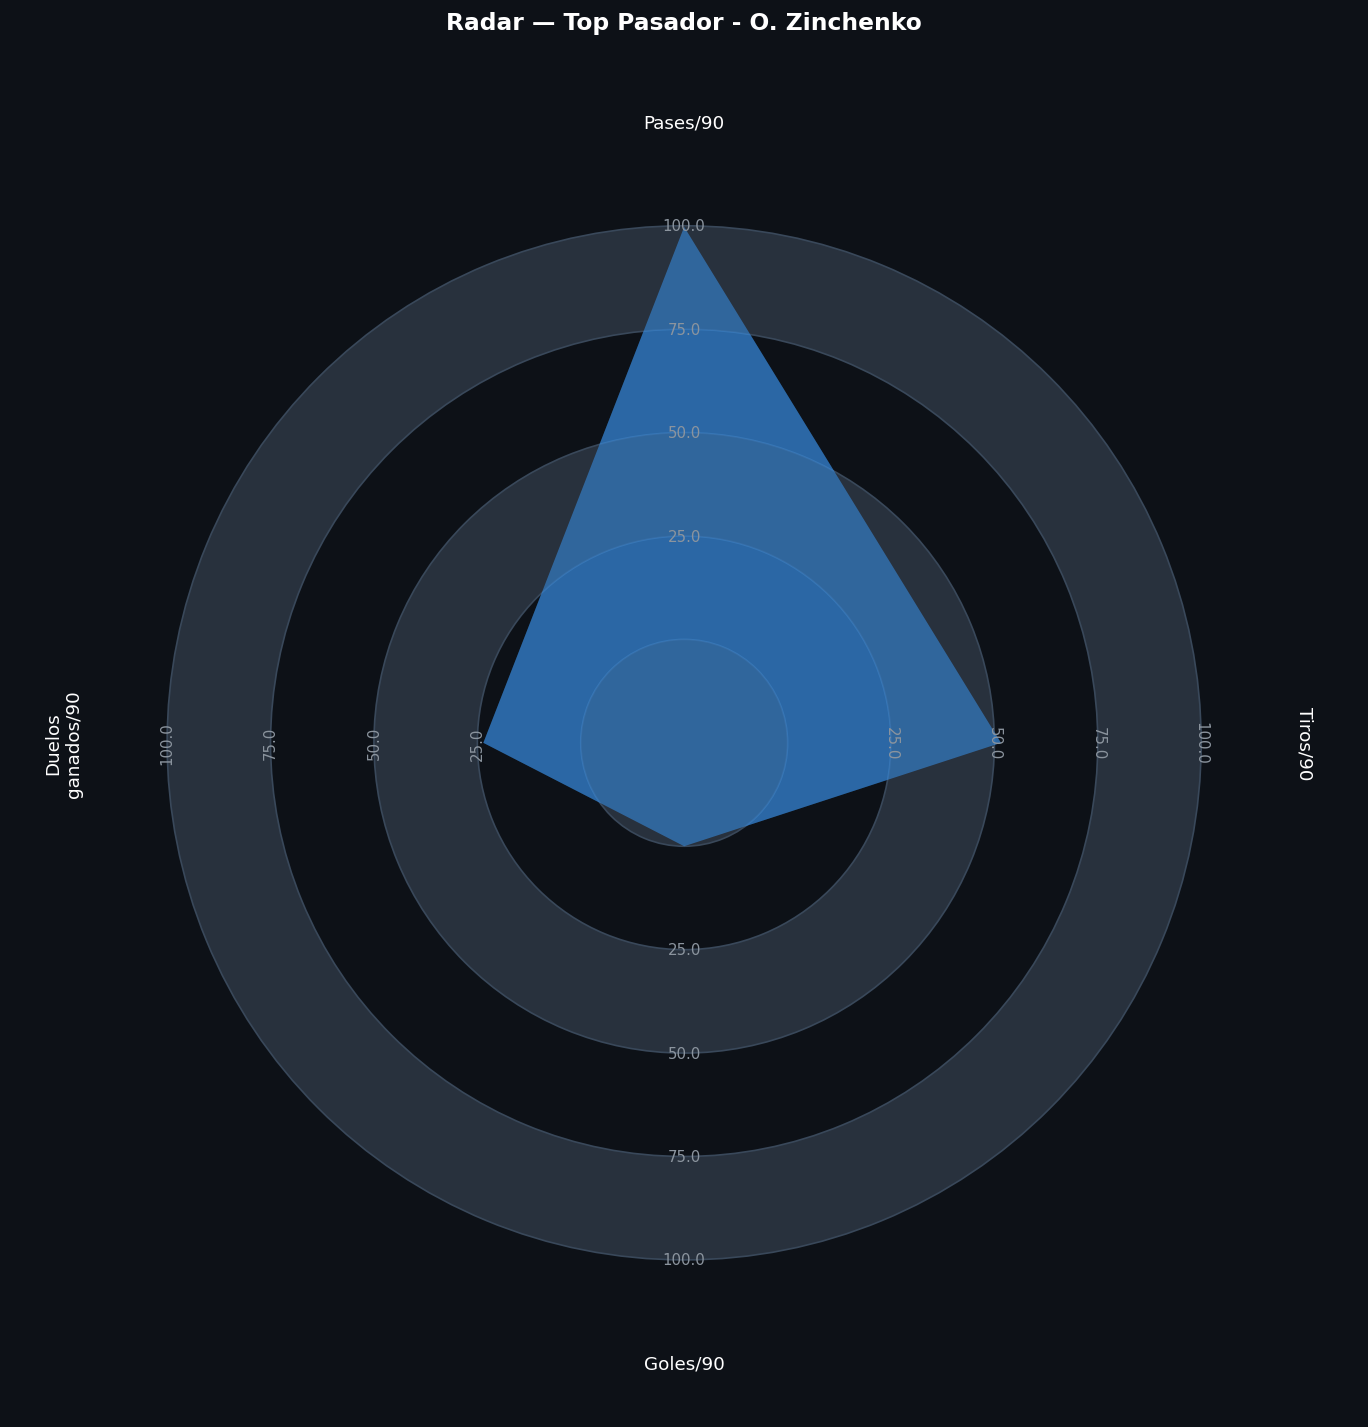

In [33]:
# Ejemplo: jugador con más pases por 90 min en la liga (mínimo 500 min jugados)
# 🔧 CAMBIO: ordenamos por passes_p90 (tasa), no total_passes (volumen crudo que
#    favorece a quien jugó más partidos, no a quien más pasa por minuto).
top_passer = player_stats.sort_values('passes_p90', ascending=False).iloc[0]
player_name = players.loc[players['wyId'] == int(top_passer['playerId']), 'shortName'].iloc[0]
plot_player_radar(top_passer, player_stats, player_name=f"Top Pasador - {player_name}")

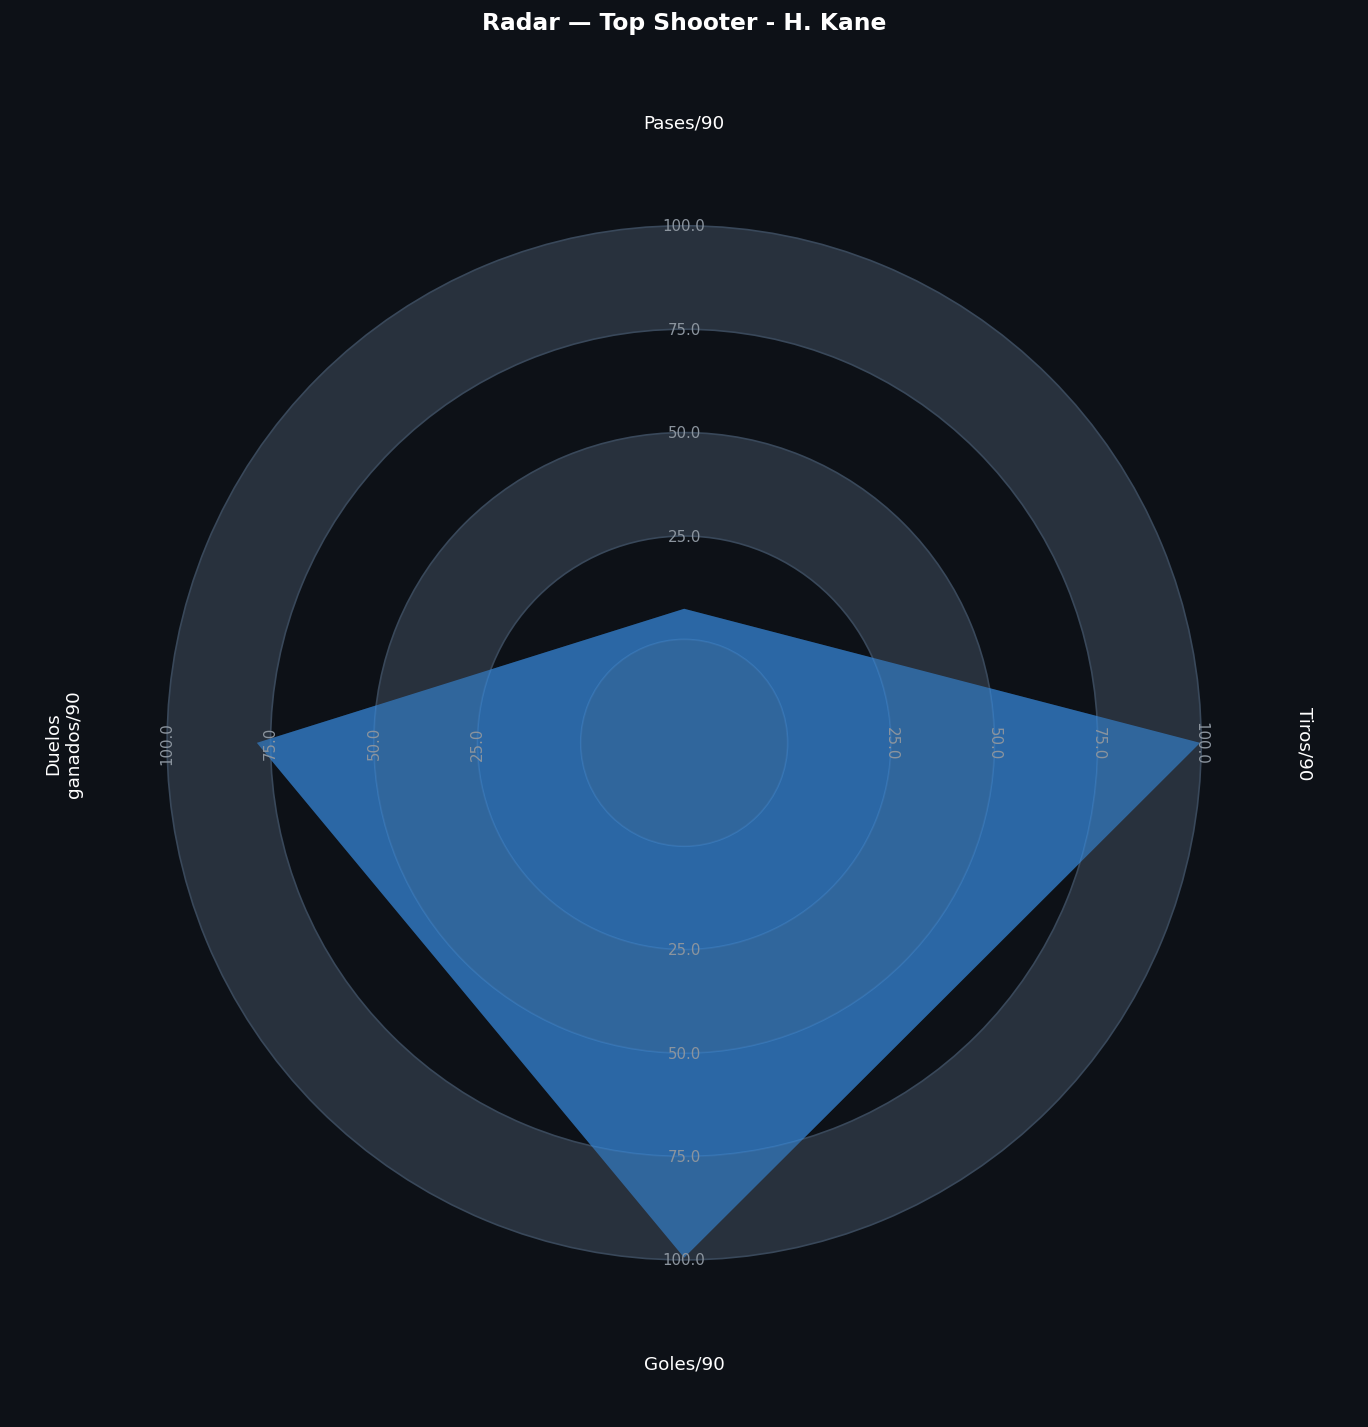

In [34]:
# Ejemplo: jugador con más tiros por 90 min en la liga (mínimo 500 min jugados)
# 🔧 CAMBIO: mismo criterio — tasa por 90, no total crudo.
top_shooter = player_stats.sort_values('shots_p90', ascending=False).iloc[0]
player_name = players.loc[players['wyId'] == int(top_shooter['playerId']), 'shortName'].iloc[0]
plot_player_radar(top_shooter, player_stats, player_name=f"Top Shooter - {player_name}")

## 7. Progressive Passes — Pases Progresivos

Un pase progresivo es aquel que avanza el balón significativamente hacia el arco rival.
La definición estándar (Wyscout/StatsBomb): pases que reducen la distancia al arco en al menos un 25%.

In [ ]:
def is_progressive_pass(row, threshold=0.25):
    """
    Determina si un pase es progresivo.
    Definición: reduce la distancia al arco rival en ≥25%.
    """
    if pd.isna(row['x']) or pd.isna(row['end_x']):
        return False
    # Distancia al arco rival (x=100 en Wyscout)
    dist_start = np.sqrt((100 - row['x'])**2 + (50 - row['y'])**2)
    dist_end   = np.sqrt((100 - row['end_x'])**2 + (50 - row['end_y'])**2)
    # En campo rival + reducción significativa
    return (dist_end < dist_start * (1 - threshold)) and (row['x'] > 30)

df_passes = df_events[
    (df_events['eventName'] == 'Pass') & 
    df_events['end_x'].notna()
].copy()

df_passes['is_progressive'] = df_passes.apply(is_progressive_pass, axis=1)

prog_rate = df_passes['is_progressive'].mean()
print(f'Pases totales: {len(df_passes):,}')
print(f'Pases progresivos: {df_passes["is_progressive"].sum():,} ({prog_rate:.1%})')

# Top jugadores por pases progresivos
prog_by_player = df_passes.groupby('playerId').agg(
    total_passes=('eventId', 'count'),
    progressive_passes=('is_progressive', 'sum')
).reset_index()
prog_by_player['prog_rate'] = prog_by_player['progressive_passes'] / prog_by_player['total_passes']
prog_by_player = prog_by_player[prog_by_player['total_passes'] >= 200]
print('\nTop 10 jugadores por pases progresivos absolutos:')
print(prog_by_player.sort_values('progressive_passes', ascending=False).head(10).to_string())

In [ ]:
# Visualización de pases progresivos vs ordinarios
pitch = Pitch(pitch_type='opta', pitch_color='#1a472a', line_color='white', line_zorder=2)
fig, axes = pitch.draw(ncols=2, figsize=(16, 6))
fig.set_facecolor('#0d1117')

for ax, (label, mask) in zip(axes, [
    ('Pases ordinarios', ~df_passes['is_progressive']),
    ('Pases progresivos', df_passes['is_progressive'])
]):
    sample = df_passes[mask].dropna(subset=['x','y','end_x','end_y']).sample(min(500, mask.sum()))
    pitch.arrows(
        sample['x'], sample['y'],
        sample['end_x'], sample['end_y'],
        ax=ax, width=0.5, alpha=0.15,
        color='#378ADD' if 'ordinarios' in label else '#FFD700'
    )
    ax.set_title(label, color='white', fontsize=12, fontweight='bold')

plt.suptitle('Pases Ordinarios vs. Progresivos — muestra de 500', 
             color='white', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 8. Actividades propuestas

### Ejercicio 1 — Shot Map por equipo
Elegí dos equipos de alguna liga (por ejemplo Manchester City y Manchester United) y comparalos
en un shot map side-by-side. ¿Qué diferencias ves en el patrón de tiros?

### Ejercicio 2 — xG semanal
Calcula el xG acumulado por jornada para los 5 principales equipos de la liga.
Graficá la evolución temporal y compará con los goles reales marcados.

¿Qué equipos están sobre-rindiendo o sub-rindiendo respecto a su xG?

### Ejercicio 3 — Red de pases más conectada
Identifica el par de jugadores con mayor número de pases entre ellos en toda la temporada.
¿Corresponde a alguna combinación táctica conocida?

### Ejercicio 4 — Radar comparativo
Elegí 3 centrocampistas del dataset y comparalos en un radar con las siguientes métricas:
pases por 90 min, pases progresivos por 90 min, duelos ganados por 90 min, xG por 90 min.

### Ejercicio 5 — Análisis de pressing
El pressing puede medirse como la densidad de recuperaciones de balón en campo rival.
Construí un heat map de recuperaciones (ball recoveries) para identificar qué equipos
presionan más alto. Usá el tag de 'Ball lost' en el campo rival.

---
**Criterios de evaluación**: calidad visual, correctitud del análisis, insights relevantes y comentarios en el código.